## Numpy 实际应用

图像其实是由若干像素组成，每一个像素都有明确的位置和被分配的颜色值，因此一张图像也就构成了一个像素矩阵，例如，一张灰度图片的像素块，如下，是一个二维数组，颜色取值为0~255，其中0为黑色，255为白色。从0-255逐渐由暗色变为亮色。

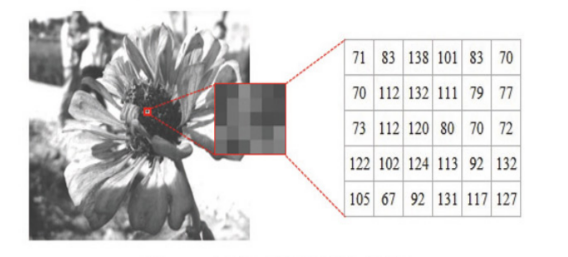

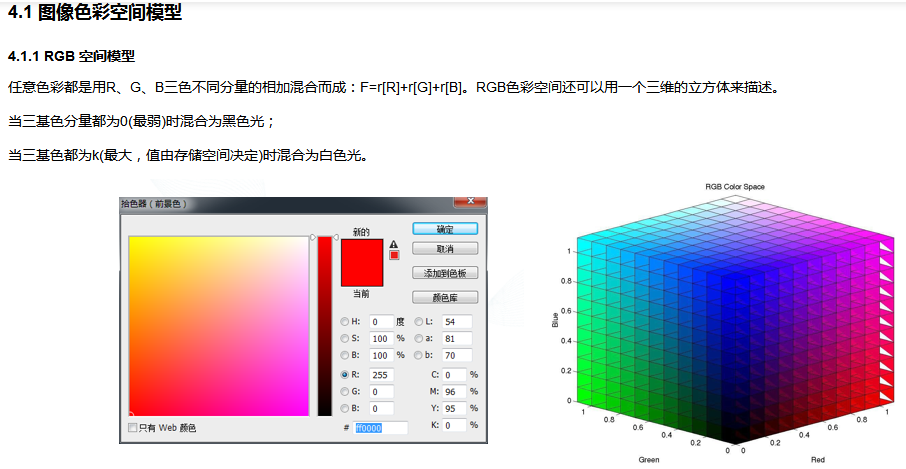

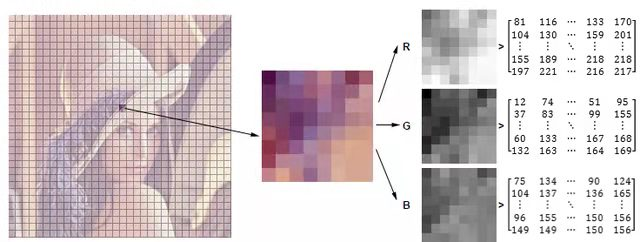

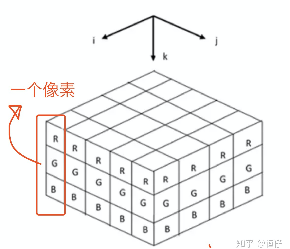

RGB转换成灰度图像的常用公式：

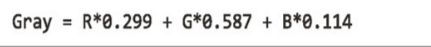

以下简单举例 Numpy 数组在图像处理领域的应用：

导入模块

In [2]:
import numpy as np
import matplotlib.pyplot as plt

读取图片并将其转化成数组数据;并显图像及数组

[[[0.3882353  0.3647059  0.30588236]
  [0.6784314  0.6431373  0.5372549 ]
  [0.7058824  0.6627451  0.5568628 ]
  ...
  [0.6627451  0.6        0.5254902 ]
  [0.6627451  0.6        0.5254902 ]
  [0.64705884 0.60784316 0.5411765 ]]

 [[0.39215687 0.36862746 0.30980393]
  [0.6901961  0.64705884 0.5411765 ]
  [0.7176471  0.6745098  0.5647059 ]
  ...
  [0.6862745  0.62352943 0.5411765 ]
  [0.68235296 0.62352943 0.5411765 ]
  [0.6745098  0.63529414 0.5529412 ]]

 [[0.39215687 0.3647059  0.30588236]
  [0.6862745  0.6431373  0.5372549 ]
  [0.7137255  0.67058825 0.56078434]
  ...
  [0.69803923 0.6392157  0.5411765 ]
  [0.69411767 0.6392157  0.5411765 ]
  [0.6901961  0.6509804  0.56078434]]

 ...

 [[0.48235294 0.4745098  0.44313726]
  [0.84705883 0.8352941  0.78039217]
  [0.88235295 0.87058824 0.8117647 ]
  ...
  [0.3647059  0.49411765 0.46666667]
  [0.36862746 0.49411765 0.46666667]
  [0.37254903 0.48235294 0.47058824]]

 [[0.4745098  0.46666667 0.43529412]
  [0.83137256 0.81960785 0.7647059 ]


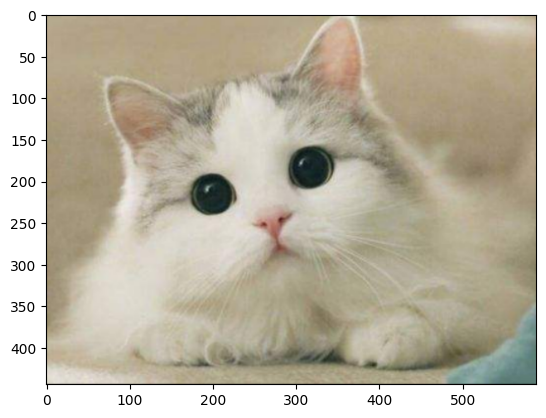

In [3]:
img_code = plt.imread('./cat.jpg')
plt.imshow(img_code)
print(img_code)

查看图像数组的形状

In [4]:
print('图像数组的形状:',img_code.shape)

图像数组的形状: (444, 589, 3)


In [ ]:
print('图像数组的维度:',img_code.ndim)
print('图像数组的类型:',img_code.dtype)

图像数组的维度: 3
图像数组的类型: float32


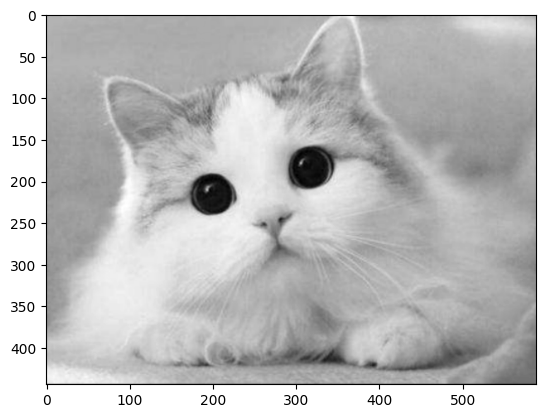

In [6]:
arr = np.array([0.299,0.587,0.114])
img_gray = np.dot(img_code,arr)
plt.imshow(img_gray,cmap='gray')

对图像颜色反转

In [19]:
img_code_reverse = 1.0 - img_code


查看数组元素类型

In [20]:
print('数组元素类型:',img_code_reverse.dtype)
# img_code_reverse = img_code_reverse.astype(np.uint8)
# print('数组元素类型:',img_code_reverse.dtype)


数组元素类型: float32


将颜色反转后的图像显示出来

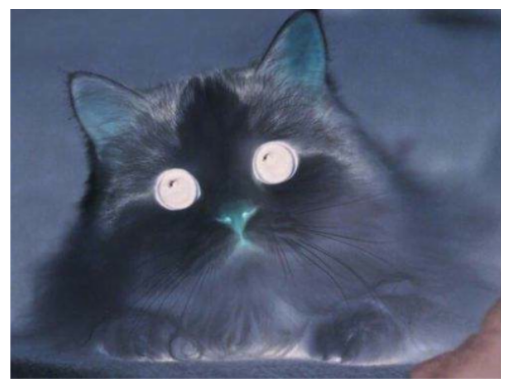

In [21]:
plt.axis('off')
plt.imshow(img_code_reverse)
plt.show()

数组列倒置，即横向翻转图像

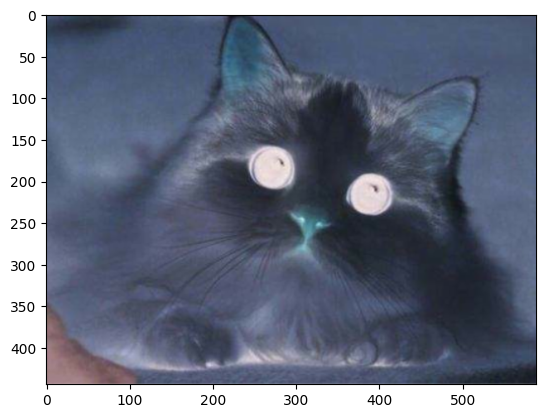

In [23]:
column_reverse = img_code_reverse[:,::-1,:]
plt.imshow(column_reverse)

数组行倒置，即纵向翻转图像

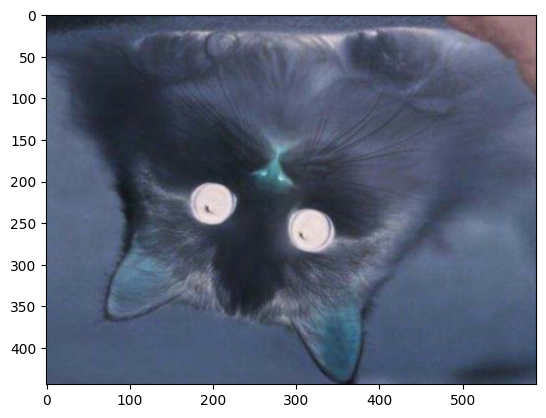

In [24]:
index_reverse = img_code_reverse[::-1,:,:]
# plt.axis('off')
plt.imshow(index_reverse)

截取图像的一部分

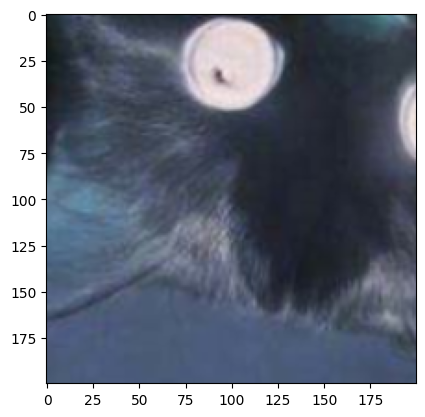

In [25]:
x_start, x_end = 200, 400 
y_start, y_end = 100, 300
crop_img = index_reverse[x_start:x_end ,y_start:y_end , :]
plt.imshow(crop_img)

组合图像

 img_gray为二维的，这里img-code为三维的，故将img_gray变为三维的，将灰度图像增加一个维度，变为 (H, W, 1)再将灰度图像复制到 3 个通道，变为 (H, W, 3)


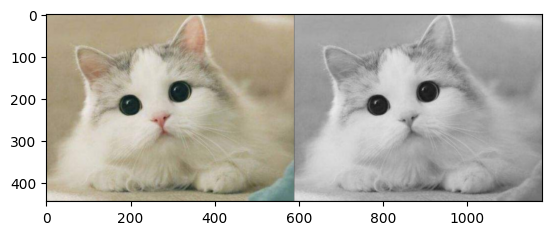

In [27]:
img_gray_3d = np.expand_dims(img_gray, axis=2)
img_gray_3d = np.repeat(img_gray_3d, 3, axis=2)
combined_img = np.hstack((img_code, img_gray_3d))
plt.imshow(combined_img)


保存图像

In [28]:
plt.imsave('combined_img.jpg',combined_img)